# PS5: Đánh giá hiệu quả hoạt động của văn phòng và đại lý theo địa bàn

## Cách tiếp cận

Phân tích được thực hiện theo đúng thứ tự của đề:

1. Suy ra danh sách văn phòng và đại lý từ mức độ tập trung khách hàng theo District.
2. Thống kê doanh thu, số hóa đơn và khách hàng phục vụ của từng đơn vị.
3. Tính doanh thu bình quân trên khách hàng và hóa đơn.
4. So sánh hiệu quả các đơn vị trong cùng Region hoặc City.
5. Xếp hạng theo KPI và xác định đơn vị hiệu quả hoặc cần cải thiện.
6. Đề xuất tối ưu mạng lưới, mở rộng hoặc tái cơ cấu.

## Quy ước suy ra đơn vị

Dataset không có mã văn phòng/đại lý thực tế, nên bài phân tích sử dụng quy ước:

- District có nhiều khách hàng nhất trong mỗi City được xem là **văn phòng trung tâm**.
- Các District còn lại có percentile số khách hàng từ 85 trở lên trong City được xem là **đại lý**.
- Mỗi District chỉ đại diện cho một đơn vị để một đơn hàng không bị tính cho cả văn phòng và đại lý.
- Đây là mô hình suy luận phục vụ phân tích, không khẳng định các đơn vị này đã tồn tại ngoài thực tế.


## Chuẩn bị dữ liệu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



customers = pd.read_csv("../../SilverData/customers_silver.csv")
geography = pd.read_csv("../../SilverData/geography_silver.csv")
orders = pd.read_csv("../../SilverData/orders_silver.csv")
payments = pd.read_csv("../../SilverData/payments_silver.csv")
returns = pd.read_csv("../../SilverData/returns_silver.csv")

print("Customers:", customers.shape)
print("Geography:", geography.shape)
print("Orders:", orders.shape)
print("Payments:", payments.shape)
print("Returns:", returns.shape)

Customers: (121930, 6)
Geography: (39948, 4)
Orders: (646945, 9)
Payments: (646945, 4)
Returns: (39939, 7)


# Phần 1: Xác định danh sách văn phòng và đại lý

Khách hàng được ánh xạ vào địa giới qua `zip`. Vì tên District có thể trùng giữa các City, mỗi địa bàn được xác định bằng `Region + City + District`.

Trong mỗi City:

- District đứng hạng 1 về số khách hàng được gán loại `Văn phòng`.
- Các District còn lại có percentile từ 85 trở lên được gán loại `Đại lý`.
- **Note: Đây là suy luận của nhóm không phải thực tế**

Sau bước này, danh sách đơn vị được giữ cố định để thực hiện năm yêu cầu KPI tiếp theo.



In [2]:
customer_location = customers.merge(
    geography,
    on="zip",
    how="left",
    validate="many_to_one",
    indicator=True
)

print("Tổng khách hàng:", customers["customer_id"].nunique())
print("Khách không ghép được địa giới:", (customer_location["_merge"] != "both").sum())

customer_by_district = (
    customer_location
    .groupby(["region", "city", "district"], as_index=False)
    .agg(total_customers=("customer_id", "nunique"))
)

customer_by_district["customer_percentile_in_city"] = (
    customer_by_district
    .groupby(["region", "city"])["total_customers"]
    .rank(method="average", pct=True)
)

customer_by_district["customer_rank_in_city"] = (
    customer_by_district
    .groupby(["region", "city"])["total_customers"]
    .rank(method="first", ascending=False)
)

# Chọn các District thuộc nhóm 15% có nhiều khách nhất trong từng City.
candidate_units = customer_by_district.loc[
    customer_by_district["customer_percentile_in_city"] >= 0.85
].copy()

# Điểm đông khách nhất là văn phòng trung tâm; các điểm còn lại là đại lý.
candidate_units["unit_type"] = "Đại lý"
candidate_units.loc[
    candidate_units["customer_rank_in_city"] == 1,
    "unit_type"
] = "Văn phòng"

candidate_units["unit_id"] = (
    candidate_units["unit_type"] + " | "
    + candidate_units["region"] + " | "
    + candidate_units["city"] + " | "
    + candidate_units["district"]
)

candidate_units = candidate_units.sort_values(
    ["region", "city", "customer_rank_in_city"]
).reset_index(drop=True)

print("Tổng số District:", len(customer_by_district))
print("Tổng số đơn vị được suy ra:", len(candidate_units))
print("Số văn phòng:", (candidate_units["unit_type"] == "Văn phòng").sum())
print("Số đại lý:", (candidate_units["unit_type"] == "Đại lý").sum())
print("Số City có đơn vị:", candidate_units["city"].nunique())



Tổng khách hàng: 121930
Khách không ghép được địa giới: 0
Tổng số District: 534
Tổng số đơn vị được suy ra: 98
Số văn phòng: 42
Số đại lý: 56
Số City có đơn vị: 42


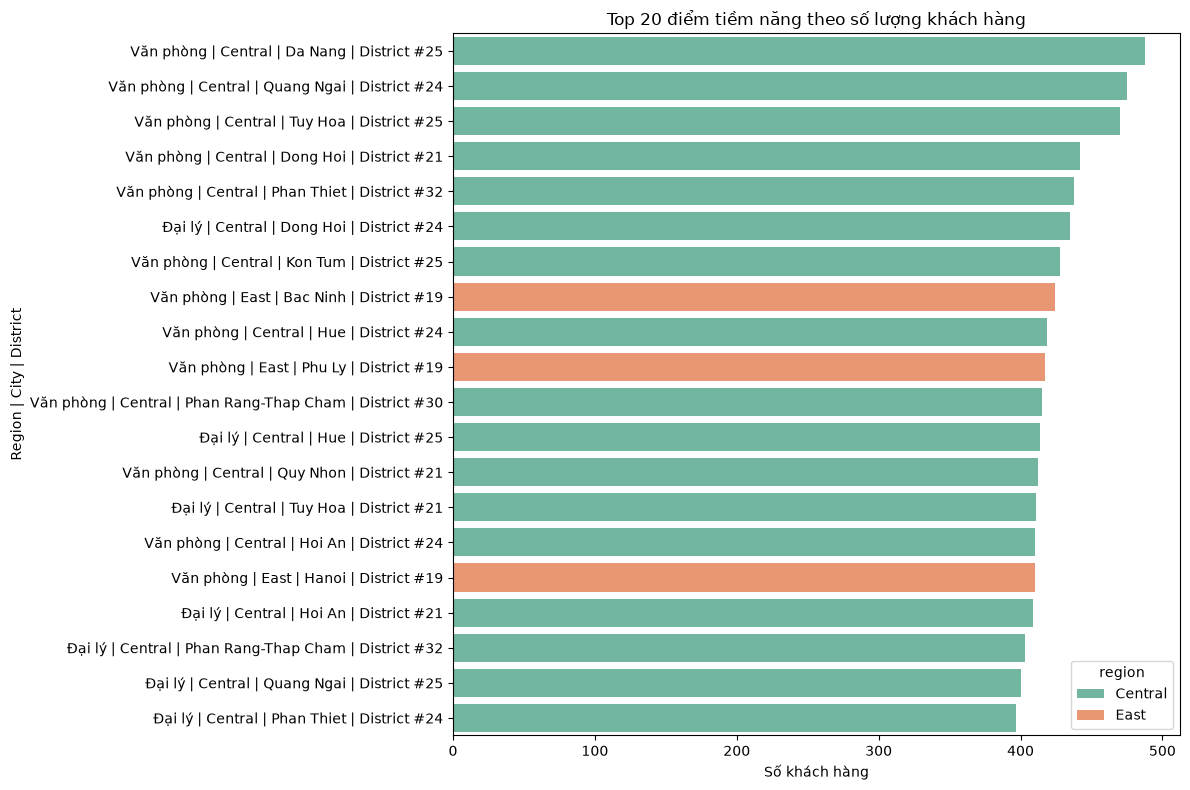

In [3]:
top_candidate = candidate_units.nlargest(20, "total_customers").copy()

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_candidate,
    x="total_customers",
    y="unit_id",
    hue="region",
    dodge=False,
    palette="Set2"
)
plt.title("Top 20 điểm tiềm năng theo số lượng khách hàng")
plt.xlabel("Số khách hàng")
plt.ylabel("Region | City | District")
plt.tight_layout()
plt.show()


## Chuẩn bị doanh thu thuần cho việc đánh giá hiệu quả hoạt động của các văn phòng/đại lý 

- Đơn `delivered`: doanh thu thuần bằng `payment_value`.
- Đơn `returned`: doanh thu thuần bằng `payment_value - total_refund`.
- Đơn `returned` thiếu dữ liệu hoàn tiền bị loại.
- Đơn có tiền hoàn vượt payment vẫn được giữ vì khoản hoàn có thể bao gồm tiền đền bù.


In [4]:
refund_by_order = (
    returns.groupby("order_id", as_index=False)
    .agg(total_refund=("refund_amount", "sum"))
)

order_revenue = (
    orders
    .merge(
        geography,
        on="zip",
        how="left",
        validate="many_to_one"
    )
    .merge(
        payments,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        refund_by_order,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
)

order_revenue = order_revenue.loc[
    order_revenue["order_status"].isin(["delivered", "returned"])
].copy()

missing_refund = (
    order_revenue["order_status"].eq("returned")
    & order_revenue["total_refund"].isna()
)
order_revenue = order_revenue.loc[~missing_refund].copy()

order_revenue["total_refund"] = order_revenue["total_refund"].fillna(0)
order_revenue["gross_revenue"] = order_revenue["payment_value"]
order_revenue["net_revenue"] = (
    order_revenue["gross_revenue"] - order_revenue["total_refund"]
)
order_revenue["refund_exceeds_payment"] = (
    order_revenue["total_refund"] > order_revenue["payment_value"]
)

print("Số đơn hợp lệ:", len(order_revenue))
print("Đơn hoàn vượt payment:", order_revenue["refund_exceeds_payment"].sum())
print("Doanh thu thuần: {:,.0f}".format(order_revenue["net_revenue"].sum()))


Số đơn hợp lệ: 552778
Đơn hoàn vượt payment: 3640
Doanh thu thuần: 12,871,731,922


# Phần 2: Thống kê doanh thu, hóa đơn và khách hàng phục vụ

Chỉ thống kê các District đã được chọn làm điểm văn phòng/đại lý tiềm năng ở phần 1.


In [5]:
district_business = (
    order_revenue
    .groupby(["region", "city", "district"], as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        refund_amount=("total_refund", "sum"),
        net_revenue=("net_revenue", "sum"),
        invoice_count=("order_id", "nunique"),
        served_customers=("customer_id", "nunique")
    )
)

unit_kpi = candidate_units.merge(
    district_business,
    on=["region", "city", "district"],
    how="left",
    validate="one_to_one"
)
business_columns = [
    "gross_revenue", "refund_amount", "net_revenue",
    "invoice_count", "served_customers"
]
unit_kpi[business_columns] = unit_kpi[business_columns].fillna(0)

part2_display = unit_kpi.sort_values("net_revenue", ascending=False).copy()
for column in ["gross_revenue", "refund_amount", "net_revenue"]:
    part2_display[column] = part2_display[column].map("{:,.0f}".format)

display(part2_display[[
    "unit_id", "unit_type", "total_customers", "served_customers",
    "invoice_count", "gross_revenue", "refund_amount", "net_revenue"
]])


,unit_id,unit_type,total_customers,served_customers,invoice_count,gross_revenue,refund_amount,net_revenue
62,Đại lý | East | Uong Bi | District #09,Đại lý,297,235,1735,"41,409,426","1,453,524","39,955,902"
34,Đại lý | East | Ha Long | District #03,Đại lý,344,287,1641,"40,823,971","1,342,908","39,481,063"
89,Đại lý | West | Rach Gia | District #36,Đại lý,192,164,1851,"40,851,024","1,439,198","39,411,827"
75,Đại lý | West | Ca Mau | District #38,Đại lý,196,154,1962,"40,881,723","1,901,866","38,979,858"
16,Văn phòng | Central | Quang Ngai | District #24,Văn phòng,475,336,1701,"39,733,960","1,544,326","38,189,634"
...,...,...,...,...,...,...,...,...
71,Đại lý | West | Bien Hoa | District #39,Đại lý,182,119,721,"16,776,000","912,387","15,863,613"
35,Đại lý | East | Ha Long | District #01,Đại lý,307,193,632,"15,864,082","659,087","15,204,995"
48,Đại lý | East | Nam Dinh | District #13,Đại lý,259,161,615,"14,490,341","545,101","13,945,240"
54,Đại lý | East | Phu Ly | District #13,Đại lý,268,161,626,"14,053,920","540,746","13,513,174"


# Phần 3: Doanh thu bình quân trên khách hàng và hóa đơn

- `revenue_per_customer = net_revenue / served_customers`
- `revenue_per_invoice = net_revenue / invoice_count`
- `customer_activation_pct = served_customers / total_customers × 100`


In [6]:
unit_kpi["revenue_per_customer"] = (
    unit_kpi["net_revenue"]
    / unit_kpi["served_customers"].replace(0, float("nan"))
)
unit_kpi["revenue_per_invoice"] = (
    unit_kpi["net_revenue"]
    / unit_kpi["invoice_count"].replace(0, float("nan"))
)
unit_kpi["customer_activation_pct"] = (
    unit_kpi["served_customers"]
    / unit_kpi["total_customers"]
    * 100
)
unit_kpi["refund_rate_pct"] = (
    unit_kpi["refund_amount"]
    / unit_kpi["gross_revenue"].replace(0, float("nan"))
    * 100
)

part3_display = unit_kpi.sort_values(
    "revenue_per_customer",
    ascending=False
).copy()

for column in ["net_revenue", "revenue_per_customer", "revenue_per_invoice"]:
    part3_display[column] = part3_display[column].map("{:,.0f}".format)

display(part3_display[[
    "unit_id", "net_revenue", "served_customers", "invoice_count",
    "revenue_per_customer", "revenue_per_invoice",
    "customer_activation_pct", "refund_rate_pct"
]])


,unit_id,net_revenue,served_customers,invoice_count,revenue_per_customer,revenue_per_invoice,customer_activation_pct,refund_rate_pct
75,Đại lý | West | Ca Mau | District #38,"38,979,858",154,1962,"253,116","19,867",78.571429,4.652117
89,Đại lý | West | Rach Gia | District #36,"39,411,827",164,1851,"240,316","21,292",85.416667,3.523039
95,Đại lý | West | Vinh Long | District #39,"30,138,662",132,1299,"228,323","23,201",65.346535,3.709461
83,Đại lý | West | Long Xuyen | District #39,"34,583,747",153,1374,"226,038","25,170",78.061224,4.631648
93,Đại lý | West | Tra Vinh | District #39,"25,114,897",120,1039,"209,291","24,172",63.829787,4.413542
...,...,...,...,...,...,...,...,...
46,Đại lý | East | Nam Dinh | District #01,"16,987,668",213,759,"79,754","22,382",65.137615,3.293908
18,Văn phòng | Central | Quy Nhon | District #21,"19,937,016",251,902,"79,430","22,103",60.922330,3.706968
35,Đại lý | East | Ha Long | District #01,"15,204,995",193,632,"78,782","24,059",62.866450,4.154585
22,Văn phòng | Central | Tuy Hoa | District #25,"20,729,955",301,965,"68,870","21,482",64.042553,3.476810


# Phần 4: So sánh hiệu quả hoạt động giữa các văn phòng trong cùng Region hoặc City

Ta sẽ dùng Region


In [7]:
office_comparison = unit_kpi.loc[
    unit_kpi["unit_type"] == "Văn phòng"
].copy()

office_comparison["revenue_rank_in_region"] = (
    office_comparison.groupby("region")["net_revenue"]
    .rank(method="dense", ascending=False)
)
office_comparison["served_customer_rank_in_region"] = (
    office_comparison.groupby("region")["served_customers"]
    .rank(method="dense", ascending=False)
)
office_comparison["revenue_per_invoice_rank_in_region"] = (
    office_comparison.groupby("region")["revenue_per_invoice"]
    .rank(method="dense", ascending=False)
)
office_comparison["invoice_count_rank_in_region"] = (
    office_comparison.groupby("region")["invoice_count"]
    .rank(method="dense", ascending=False)
)
office_comparison = office_comparison.sort_values(
    ["region", "revenue_rank_in_region"]
)
display(office_comparison[[
    "region", "city", "district", 
    "revenue_rank_in_region", "served_customer_rank_in_region",
    "revenue_per_invoice_rank_in_region", "invoice_count_rank_in_region"
]])


,region,city,district,revenue_rank_in_region,served_customer_rank_in_region,revenue_per_invoice_rank_in_region,invoice_count_rank_in_region
16,Central,Quang Ngai,District #24,1.0,1.0,9.0,1.0
0,Central,Da Nang,District #25,2.0,2.0,8.0,2.0
4,Central,Hoi An,District #24,3.0,5.0,10.0,3.0
6,Central,Hue,District #24,4.0,4.0,5.0,4.0
8,Central,Kon Tum,District #25,5.0,6.0,7.0,5.0
12,Central,Phan Rang-Thap Cham,District #30,6.0,10.0,2.0,6.0
14,Central,Phan Thiet,District #32,7.0,11.0,3.0,7.0
20,Central,Tam Ky,District #30,8.0,12.0,1.0,10.0
10,Central,Nha Trang,District #21,9.0,9.0,6.0,8.0
2,Central,Dong Hoi,District #21,10.0,7.0,4.0,12.0


# Phần 5: Xếp hạng các văn phòng hoặc đại lý theo các chỉ số KPI và xác định các đơn vị hoạt động hiệu quả hoặc cần cải thiện

Điểm KPI là trung bình thứ hạng phần trăm của năm chỉ số:

- Doanh thu thuần.
- Số khách hàng phục vụ.
- Doanh thu/khách hàng.
- Doanh thu/hóa đơn.
- Tỷ lệ khách hàng đã được khai thác.



In [8]:
kpi_columns = [
    "net_revenue",
    "served_customers",
    "revenue_per_customer",
    "revenue_per_invoice",
    "customer_activation_pct"
]

score_columns = []
for column in kpi_columns:
    score_column = column + "_score"
    unit_kpi[score_column] = unit_kpi[column].rank(pct=True)
    score_columns.append(score_column)

unit_kpi["kpi_score"] = unit_kpi[score_columns].mean(axis=1) * 100
unit_kpi = unit_kpi.sort_values("kpi_score", ascending=False).reset_index(drop=True)
unit_kpi["overall_rank"] = range(1, len(unit_kpi) + 1)

lower_quartile = unit_kpi["kpi_score"].quantile(0.25)
upper_quartile = unit_kpi["kpi_score"].quantile(0.75)

unit_kpi["performance_group"] = "Hoạt động ổn định"
unit_kpi.loc[
    unit_kpi["kpi_score"] >= upper_quartile,
    "performance_group"
] = "Hiệu quả cao"
unit_kpi.loc[
    unit_kpi["kpi_score"] <= lower_quartile,
    "performance_group"
] = "Cần cải thiện"

print("Phân nhóm hiệu quả:")
display(unit_kpi["performance_group"].value_counts())

ranking_display = unit_kpi.copy()
for column in ["net_revenue", "revenue_per_customer", "revenue_per_invoice"]:
    ranking_display[column] = ranking_display[column].map("{:,.0f}".format)

display(ranking_display[[
    "overall_rank", "unit_id", "unit_type", "total_customers", "served_customers",
    "invoice_count", "net_revenue", "revenue_per_customer",
    "revenue_per_invoice", "customer_activation_pct",
    "kpi_score", "performance_group"
]])


Phân nhóm hiệu quả:


performance_group
Hoạt động ổn định    48
Hiệu quả cao         25
Cần cải thiện        25
Name: count, dtype: int64

,overall_rank,unit_id,unit_type,total_customers,served_customers,invoice_count,net_revenue,revenue_per_customer,revenue_per_invoice,customer_activation_pct,kpi_score,performance_group
0,1,Đại lý | East | Ha Long | District #03,Đại lý,344,287,1641,"39,481,063","137,565","24,059",83.430233,88.775510,Hiệu quả cao
1,2,Đại lý | East | Phu Ly | District #01,Đại lý,355,255,1314,"35,915,061","140,843","27,333",71.830986,84.081633,Hiệu quả cao
2,3,Đại lý | East | Uong Bi | District #09,Đại lý,297,235,1735,"39,955,902","170,025","23,029",79.124579,81.122449,Hiệu quả cao
3,4,Đại lý | West | Long Xuyen | District #39,Đại lý,196,153,1374,"34,583,747","226,038","25,170",78.061224,77.346939,Hiệu quả cao
4,5,Đại lý | East | Bac Ninh | District #03,Đại lý,291,237,1165,"29,468,270","124,339","25,295",81.443299,76.734694,Hiệu quả cao
...,...,...,...,...,...,...,...,...,...,...,...,...
93,94,Văn phòng | West | Da Lat | District #33,Văn phòng,226,139,959,"19,078,910","137,258","19,895",61.504425,23.265306,Cần cải thiện
94,95,Văn phòng | East | Thai Nguyen | District #01,Văn phòng,333,210,559,"12,416,315","59,125","22,212",63.063063,22.755102,Cần cải thiện
95,96,Đại lý | East | Nam Dinh | District #13,Đại lý,259,161,615,"13,945,240","86,616","22,675",62.162162,21.530612,Cần cải thiện
96,97,Đại lý | East | Bac Ninh | District #07,Đại lý,281,166,736,"16,486,286","99,315","22,400",59.074733,20.816327,Cần cải thiện


# Phần 6: Đề xuất giải pháp tối ưu hóa mạng lưới phân phối, mở rộng thị trường hoặc tái cơ cấucác khu vực hoạt động.

Loại đơn vị (`Văn phòng` hoặc `Đại lý`) đã được xác định ở phần 1. Phần này sử dụng KPI để đề xuất hành động cho từng đơn vị:

- **Ưu tiên mở rộng:** đơn vị thuộc nhóm hiệu quả cao.
- **Tăng khai thác khách hàng:** đơn vị chưa đạt hiệu quả cao và có tỷ lệ khách đã mua dưới trung vị.
- **Duy trì và theo dõi:** đơn vị hoạt động ổn định, tỷ lệ khai thác không thấp.
- **Khảo sát trước khi tái cơ cấu:** đơn vị cần cải thiện nhưng tỷ lệ khai thác không thấp; cần kiểm tra chi phí, sản phẩm và nhu cầu địa phương.


In [9]:
median_activation = unit_kpi["customer_activation_pct"].median()

unit_kpi["recommendation"] = "Duy trì và theo dõi"

unit_kpi.loc[
    unit_kpi["performance_group"].eq("Hiệu quả cao"),
    "recommendation"
] = "Ưu tiên mở rộng"

unit_kpi.loc[
    ~unit_kpi["performance_group"].eq("Hiệu quả cao")
    & unit_kpi["customer_activation_pct"].lt(median_activation),
    "recommendation"
] = "Tăng khai thác khách hàng"

unit_kpi.loc[
    unit_kpi["performance_group"].eq("Cần cải thiện")
    & unit_kpi["customer_activation_pct"].ge(median_activation),
    "recommendation"
] = "Khảo sát trước khi tái cơ cấu"

print("Số điểm theo đề xuất:")
display(unit_kpi["recommendation"].value_counts())

recommendation_display = unit_kpi.copy()
recommendation_display["net_revenue"] = recommendation_display["net_revenue"].map("{:,.0f}".format)

display(recommendation_display[[
    "overall_rank", "unit_id", "unit_type", "total_customers", "served_customers",
    "net_revenue", "customer_activation_pct", "kpi_score",
    "performance_group", "recommendation"
]])


Số điểm theo đề xuất:


recommendation
Tăng khai thác khách hàng        47
Ưu tiên mở rộng                  25
Duy trì và theo dõi              24
Khảo sát trước khi tái cơ cấu     2
Name: count, dtype: int64

,overall_rank,unit_id,unit_type,total_customers,served_customers,net_revenue,customer_activation_pct,kpi_score,performance_group,recommendation
0,1,Đại lý | East | Ha Long | District #03,Đại lý,344,287,"39,481,063",83.430233,88.775510,Hiệu quả cao,Ưu tiên mở rộng
1,2,Đại lý | East | Phu Ly | District #01,Đại lý,355,255,"35,915,061",71.830986,84.081633,Hiệu quả cao,Ưu tiên mở rộng
2,3,Đại lý | East | Uong Bi | District #09,Đại lý,297,235,"39,955,902",79.124579,81.122449,Hiệu quả cao,Ưu tiên mở rộng
3,4,Đại lý | West | Long Xuyen | District #39,Đại lý,196,153,"34,583,747",78.061224,77.346939,Hiệu quả cao,Ưu tiên mở rộng
4,5,Đại lý | East | Bac Ninh | District #03,Đại lý,291,237,"29,468,270",81.443299,76.734694,Hiệu quả cao,Ưu tiên mở rộng
...,...,...,...,...,...,...,...,...,...,...
93,94,Văn phòng | West | Da Lat | District #33,Văn phòng,226,139,"19,078,910",61.504425,23.265306,Cần cải thiện,Tăng khai thác khách hàng
94,95,Văn phòng | East | Thai Nguyen | District #01,Văn phòng,333,210,"12,416,315",63.063063,22.755102,Cần cải thiện,Tăng khai thác khách hàng
95,96,Đại lý | East | Nam Dinh | District #13,Đại lý,259,161,"13,945,240",62.162162,21.530612,Cần cải thiện,Tăng khai thác khách hàng
96,97,Đại lý | East | Bac Ninh | District #07,Đại lý,281,166,"16,486,286",59.074733,20.816327,Cần cải thiện,Tăng khai thác khách hàng
